<a href="https://colab.research.google.com/github/kirtia1289/chromium/blob/main/imdb_data_nlk_proj2_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**•DOMAIN:** Digital content and entertainment industry<br/>
**•CONTEXT:** The objective of this project is to build a text classification model that
analyses the customer's sentiments based on their reviews in the IMDB database. The
model uses a complex deep learning model to build an embedding layer followed by
a classification algorithm to analyse the sentiment of the customers.<br/>
**• DATA DESCRIPTION:** The Dataset of 50,000 movie reviews from IMDB, labelled by
sentiment (positive/negative). Reviews have been preprocessed, and each review is
encoded as a sequence of word indexes (integers). For convenience, the words are
indexed by their frequency in the dataset, meaning the for that has index 1 is the
most frequent word. Use the first 20 words from each review to speed up training,
using a max vocabulary size of 10,000. As a convention, "0" does not stand for a
specific word, but instead is used to encode any unknown word.<br/>

**• PROJECT OBJECTIVE:** Build a sequential NLP classifier which can use input text
parameters to determine the customer sentiments.<br/>


**Importing necessary packages**

In [10]:
import numpy as np
import pandas as pd

**STEP -1 import and analyze the data set**

In [11]:
#loading imdb data with most frequent 10000 words

from keras.datasets import imdb
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)


**Let's check dimentions of dataset**

In [12]:
X_train.shape

(25000,)

In [13]:
X_test.shape

(25000,)

**Function to perform relevant sequence adding on the data**

In [14]:
def vectorize(sequences, dimension = 10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results



In [15]:
#consolidating data for EDA
data = np.concatenate((X_train, X_test), axis=0)
label = np.concatenate((y_train, y_test), axis=0)

In [16]:
print("Categories:", np.unique(label))
print("Number of unique words:", len(np.unique(np.hstack(data))))

Categories: [0 1]
Number of unique words: 9998


In [17]:
length = [len(i) for i in data]
print("Average Review length:", np.mean(length))
print("Standard Deviation:", round(np.std(length)))

Average Review length: 234.75892
Standard Deviation: 173


**Let's look at a single training example:**

In [18]:
print("Label:", label[0])


Label: 1


In [19]:
print(data[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


**Let's decode the first review**

In [20]:
index = imdb.get_word_index()
reverse_index = dict([(value, key) for (key, value) in index.items()])
decoded = " ".join( [reverse_index.get(i - 3, "#") for i in data[0]] )
print(decoded)

# this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert # is an amazing actor and now the same being director # father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for # and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also # to the two little boy's that played the # of norman and paul they were just brilliant children are often left out of the # list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [21]:
#Adding sequence to data
data = vectorize(data)
label = np.array(label).astype("float32")


In [22]:
label

array([1., 0., 0., ..., 0., 0., 0.], dtype=float32)

**Let's check distribution of data**

In [23]:
#To plot for EDA
import seaborn as sns
sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='label', ylabel='count'>

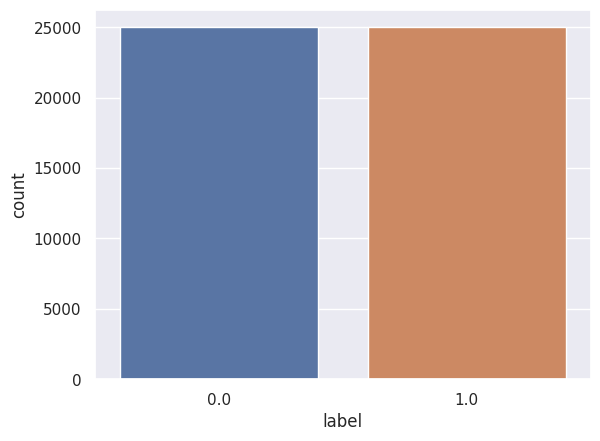

In [24]:
labelDF=pd.DataFrame({'label':label})
sns.countplot(x='label', data=labelDF)

For above analysis it is clear that data has equel distribution of sentiments.This will help us building a good model.

**Creating train and test data set**

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data,label, test_size=0.30, random_state=1)

In [26]:
X_train.shape

(35000, 10000)

In [27]:
X_test.shape

(15000, 10000)

**Let's create  sequential model**

In [2]:
from keras.utils import to_categorical
from keras import models
from keras import layers

In [3]:
model = models.Sequential()
# Input - Layer
model.add(layers.Dense(50, activation = "relu", input_shape=(10000, )))
# Hidden - Layers
model.add(layers.Dropout(0.3, noise_shape=None, seed=None))
model.add(layers.Dense(50, activation = "relu"))
model.add(layers.Dropout(0.2, noise_shape=None, seed=None))
model.add(layers.Dense(50, activation = "relu"))
# Output- Layer
model.add(layers.Dense(1, activation = "sigmoid"))
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                500050    
                                                                 
 dropout (Dropout)           (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 50)                2550      
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense_2 (Dense)             (None, 50)                2550      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 505201 (1.93 MB)
Trainable params: 505201 

In [4]:
#For early stopping
import tensorflow as tf
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

In [5]:
model.compile(
 optimizer = "adam",
 loss = "binary_crossentropy",
 metrics = ["accuracy"]
)

In [8]:
results = model.fit(X_train, y_train,
 epochs= 100,
 batch_size = 40,
 validation_data = (X_test, y_test),
 callbacks=[callback]
)

NameError: ignored

**Let's check mean accuracy of our model**

In [10]:
print(np.mean(results.history["val_accuracy"]))

NameError: ignored

In [ ]:
#Let's plot training history of our model

# list all data in history
print(results.history.keys())
# summarize history for accuracy
plt.plot(results.history['accuracy'])
plt.plot(results.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
model.predict(X_test)